# Data Analysis

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

In [62]:
snd_cert = ["snd-cert/snd-cert.1.test", "snd-cert/snd-cert.2.test", "snd-cert/snd-cert.3.test"]
snd_unm = ["snd-unm/snd-unm.1.test", "snd-unm/snd-unm.2.test", "snd-unm/snd-unm.3.test"]
files = snd_cert + snd_unm

lengths = []

for file in files:
    with open(f"syscalls/{file}", "r") as f:
        for line in f:
            lengths.append(len(line))

lengths = np.array(lengths)

In [63]:
np.min(lengths), np.max(lengths)

(8, 1001)

In [64]:
np.mean(lengths)

807.5205882352941

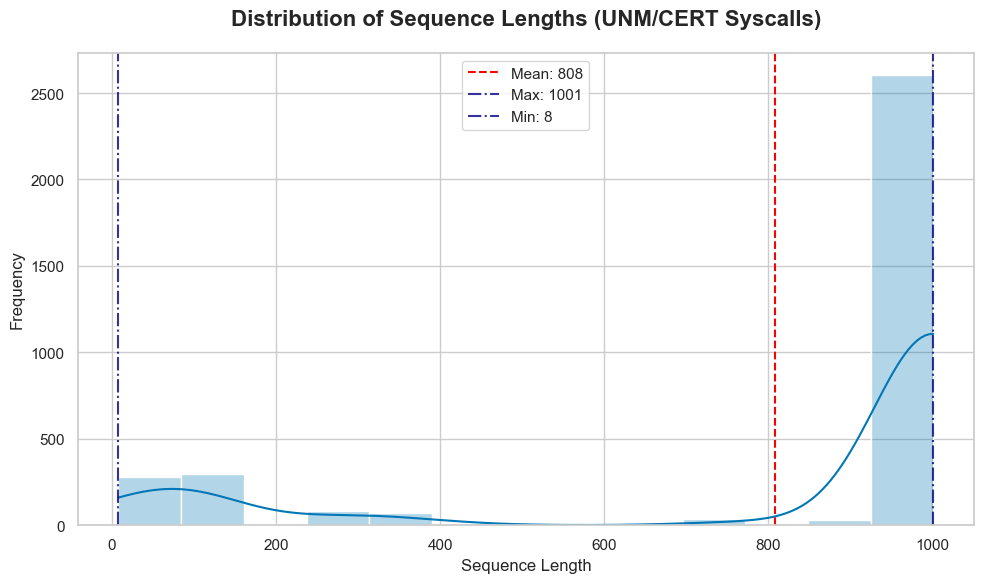

In [65]:
plt.figure(figsize=(10, 6))


sns.histplot(
    lengths, 
    kde=True, 
    stat="count",  
    fill=True,
    alpha=0.3,
    color="#0077b6",
    edgecolor=None
)

plt.title('Distribution of Sequence Lengths (UNM/CERT Syscalls)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Sequence Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
plt.axvline(np.max(lengths), color='navy', alpha=0.8, linestyle='-.', label=f'Max: {np.max(lengths):.0f}')
plt.axvline(np.min(lengths), color='navy', alpha=0.8, linestyle='-.', label=f'Min: {np.min(lengths):.0f}')
plt.legend(loc='upper center')

plt.tight_layout()
plt.show()


In [66]:
np.sum(lengths<10), np.sum(lengths>=10)

(167, 3233)

In [22]:
lengths = []

for file in snd_cert:
    with open(f"syscalls/{file}", "r") as f:
        for line in f:
            lengths.append(len(line))

lengths = np.array(lengths)

In [23]:
np.min(lengths), np.max(lengths)

(8, 1001)

In [24]:
np.mean(lengths)

798.0711764705883

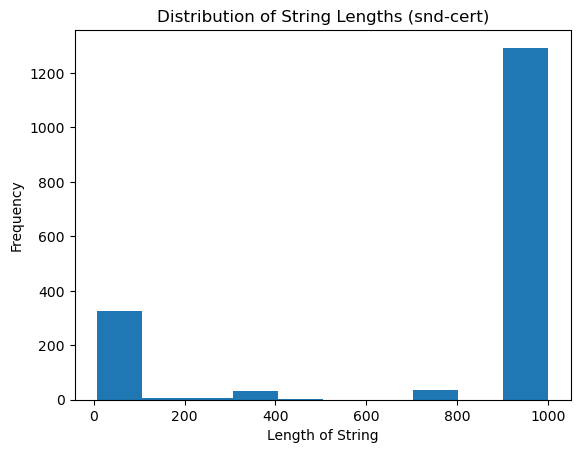

In [25]:
plt.hist(lengths, bins=10)
plt.title('Distribution of String Lengths (snd-cert)')
plt.xlabel('Length of String')
plt.ylabel('Frequency')
plt.show()

In [26]:
lengths = []

for file in snd_unm:
    with open(f"syscalls/{file}", "r") as f:
        for line in f:
            lengths.append(len(line))

lengths = np.array(lengths)

In [27]:
np.min(lengths), np.max(lengths)

(8, 1001)

In [28]:
np.mean(lengths)

816.97

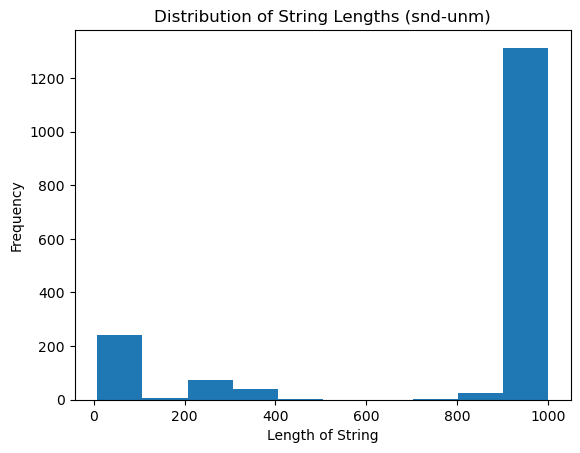

In [30]:
plt.hist(lengths, bins=10)
plt.title('Distribution of String Lengths (snd-unm)')
plt.xlabel('Length of String')
plt.ylabel('Frequency')
plt.show()

# Preprocessing

In [80]:
import subprocess

In [81]:
def create_chunks(file, out, n):
    with open(file, 'r') as f_in, open(out, 'w') as f_out:
        for line in f_in:
            seq = line.strip()
            for i in range(len(seq) - n + 1):
                f_out.write(seq[i:i+n] + "\n")

def pipeline(train, alphabet, test, n, r):
    chunk_train = f"chunks_n_{n}_r_{r}.train"
    create_chunks(train, chunk_train, n)
    cmd = [
        "java", "-jar", "negsel2.jar",
        "-alphabet", f"{alphabet}",
        "-self", f"{chunk_train}", 
        "-n", str(n), 
        "-r", str(r), 
        "-c", "-l"
    ]
    results = []
    with open(test, 'r') as f:
        for line in f:
            seq = line.strip()
            chunks = [seq[i:i+n] for i in range(len(seq) - n + 1)]
            result = subprocess.run(cmd, input="\n".join(chunks), capture_output=True, text=True)
            scores = [float(s) for s in result.stdout.splitlines() if s.strip()]
            avg_score = sum(scores) / len(scores) if scores else 0.0
            results.append(avg_score)
    return results

# Evaluation

## Parameter Search

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [ ]:
parameters = [ 
    (10, 5),
    (11, 6),
    (13, 3)
]

In [84]:
with open("syscalls/snd-cert/snd-cert.1.labels", "r") as f:
    y_true_1 = [int(line.strip()) for line in f]
with open("syscalls/snd-cert/snd-cert.2.labels", "r") as f:
    y_true_2 = [int(line.strip()) for line in f]
with open("syscalls/snd-cert/snd-cert.3.labels", "r") as f:
    y_true_3 = [int(line.strip()) for line in f]

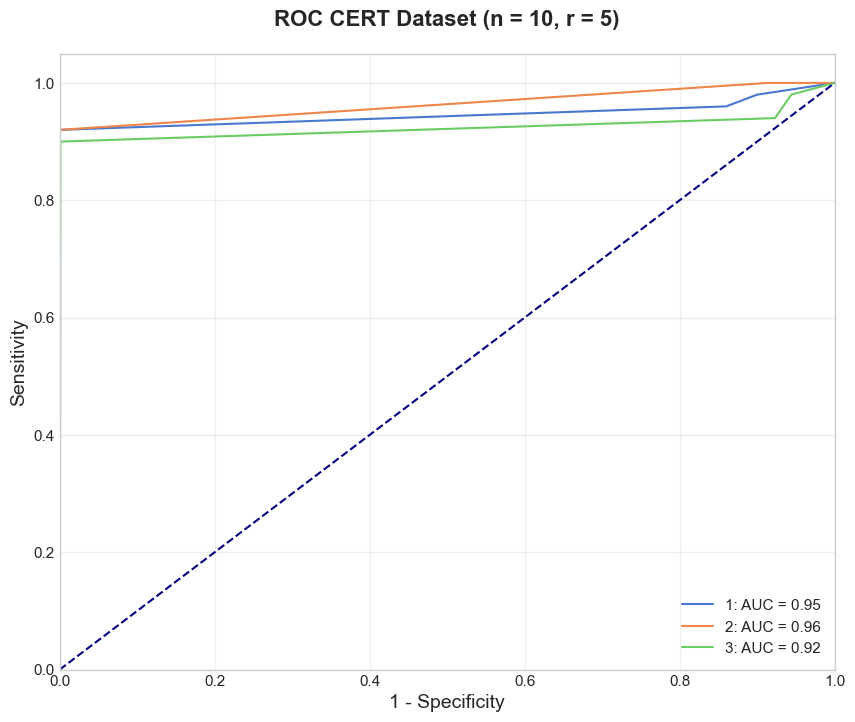

In [86]:
plt.figure(figsize=(10, 8))

n = 10
r = 5
y_scores_1 = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.1.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true_1, y_scores_1)
auc_score = auc(x, y)
plt.plot(x, y, label=f'1: AUC = {auc_score:.2f}')

y_scores_2 = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.2.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true_2, y_scores_2)
auc_score = auc(x, y)
plt.plot(x, y, label=f'2: AUC = {auc_score:.2f}')

y_scores_3 = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.3.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true_3, y_scores_3)
auc_score = auc(x, y)
plt.plot(x, y, label=f'3: AUC = {auc_score:.2f}')


plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity', fontsize=14)
plt.ylabel('Sensitivity', fontsize=14)
plt.title(f'ROC CERT Dataset (n = {n}, r = {r})', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

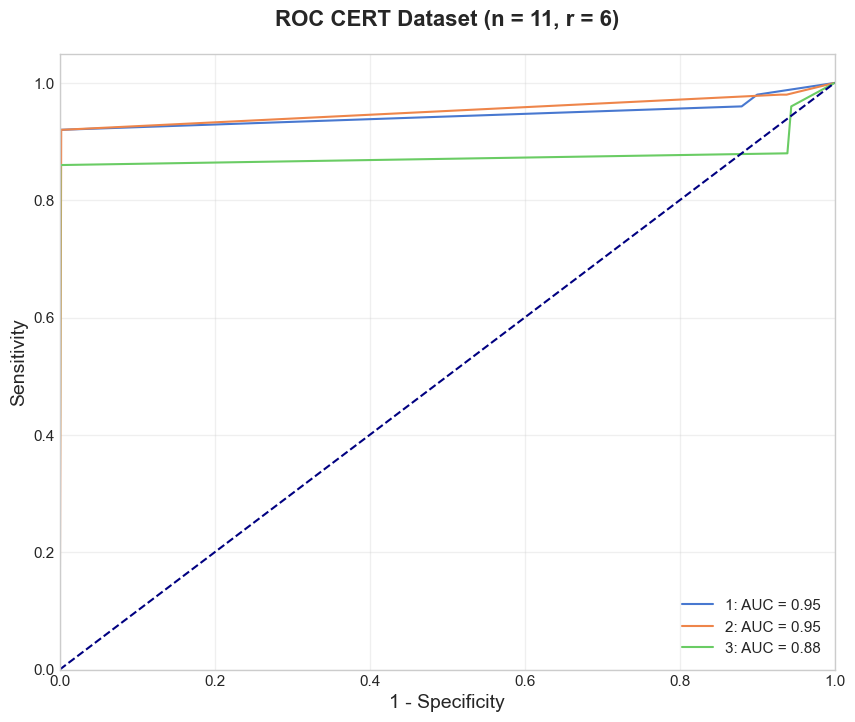

In [88]:
plt.figure(figsize=(10, 8))

n = 11
r = 6
y_scores_1 = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.1.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true_1, y_scores_1)
auc_score = auc(x, y)
plt.plot(x, y, label=f'1: AUC = {auc_score:.2f}')

y_scores_2 = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.2.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true_2, y_scores_2)
auc_score = auc(x, y)
plt.plot(x, y, label=f'2: AUC = {auc_score:.2f}')

y_scores_3 = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.3.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true_3, y_scores_3)
auc_score = auc(x, y)
plt.plot(x, y, label=f'3: AUC = {auc_score:.2f}')


plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity', fontsize=14)
plt.ylabel('Sensitivity', fontsize=14)
plt.title(f'ROC CERT Dataset (n = {n}, r = {r})', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

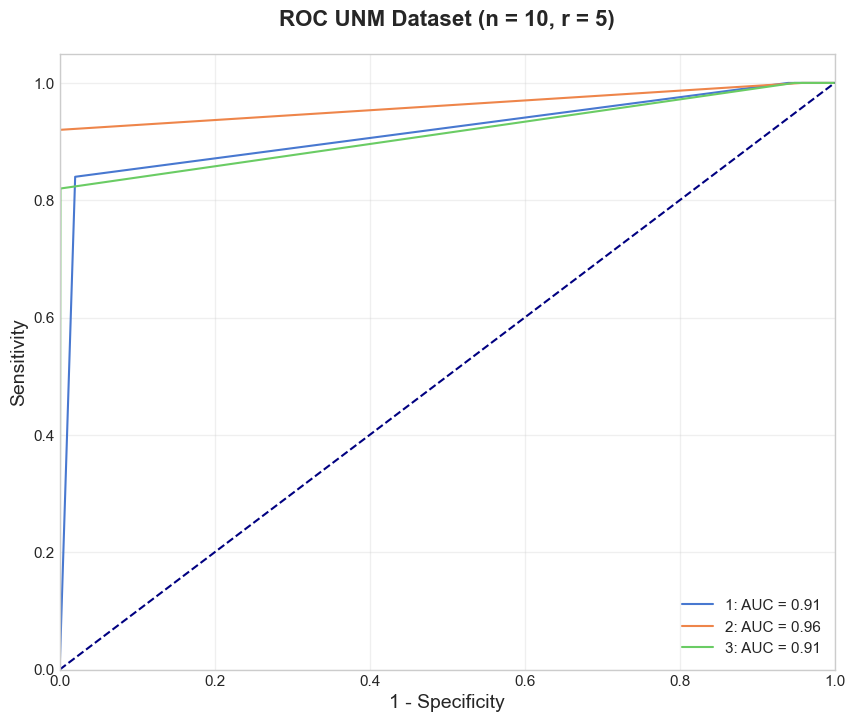

In [89]:
with open("syscalls/snd-unm/snd-unm.1.labels", "r") as f:
    y_true_1 = [int(line.strip()) for line in f]
with open("syscalls/snd-unm/snd-unm.2.labels", "r") as f:
    y_true_2 = [int(line.strip()) for line in f]
with open("syscalls/snd-unm/snd-unm.3.labels", "r") as f:
    y_true_3 = [int(line.strip()) for line in f]

plt.figure(figsize=(10, 8))

n = 10
r = 5
y_scores_1 = pipeline(
        train="syscalls/snd-unm/snd-unm.train",
        alphabet="syscalls/snd-unm/snd-unm.alpha", 
        test="syscalls/snd-unm/snd-unm.1.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true_1, y_scores_1)
auc_score = auc(x, y)
plt.plot(x, y, label=f'1: AUC = {auc_score:.2f}')

y_scores_2 = pipeline(
        train="syscalls/snd-unm/snd-unm.train",
        alphabet="syscalls/snd-unm/snd-unm.alpha", 
        test="syscalls/snd-unm/snd-unm.2.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true_2, y_scores_2)
auc_score = auc(x, y)
plt.plot(x, y, label=f'2: AUC = {auc_score:.2f}')

y_scores_3 = pipeline(
        train="syscalls/snd-unm/snd-unm.train",
        alphabet="syscalls/snd-unm/snd-unm.alpha", 
        test="syscalls/snd-unm/snd-unm.3.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true_3, y_scores_3)
auc_score = auc(x, y)
plt.plot(x, y, label=f'3: AUC = {auc_score:.2f}')


plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity', fontsize=14)
plt.ylabel('Sensitivity', fontsize=14)
plt.title(f'ROC UNM Dataset (n = {n}, r = {r})', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

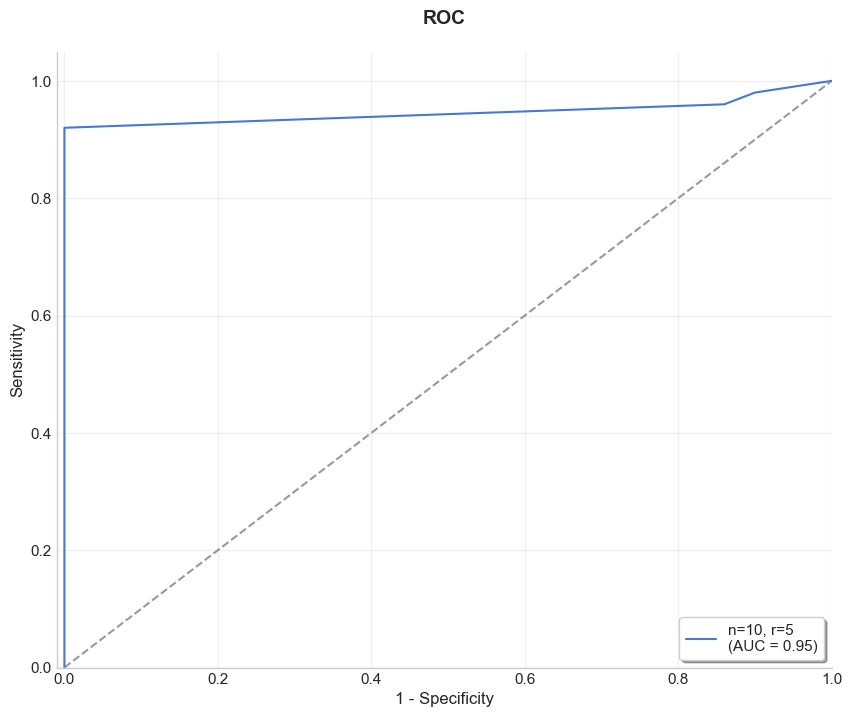

In [75]:
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')
n = 10
r= 5
y_scores = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.1.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true, y_scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'n={n}, r={r}\n(AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', alpha=0.8)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity', fontsize=12, fontweight='500')
plt.ylabel('Sensitivity', fontsize=12, fontweight='500')
plt.title('ROC', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="lower right", frameon=True, fontsize=11, shadow=True)
plt.grid(alpha=0.3)
plt.show()

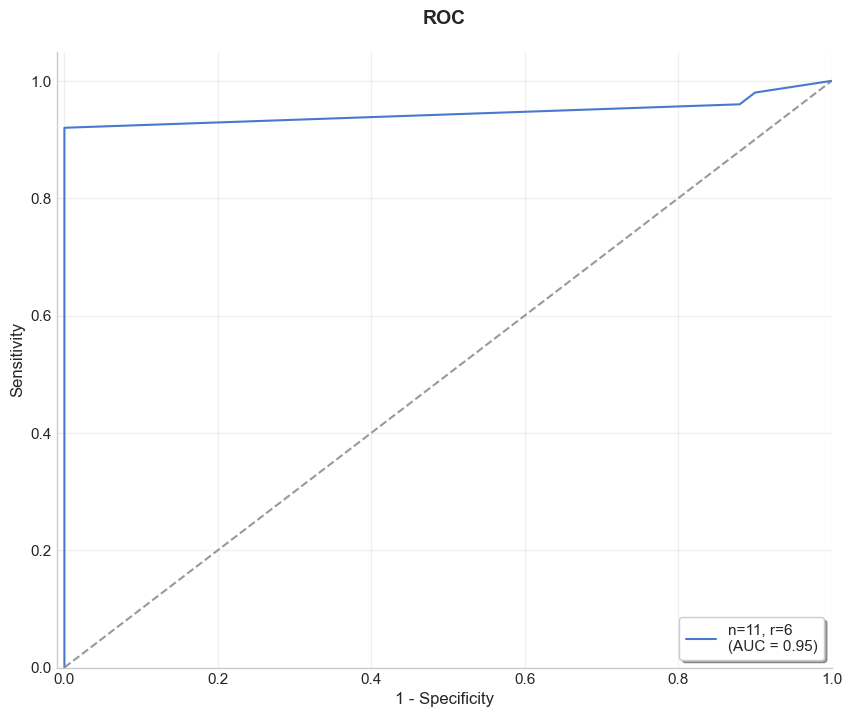

In [76]:
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')
n = 11
r= 6
y_scores = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.1.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true, y_scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'n={n}, r={r}\n(AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', alpha=0.8)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity', fontsize=12, fontweight='500')
plt.ylabel('Sensitivity', fontsize=12, fontweight='500')
plt.title('ROC', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="lower right", frameon=True, fontsize=11, shadow=True)
plt.grid(alpha=0.3)
plt.show()

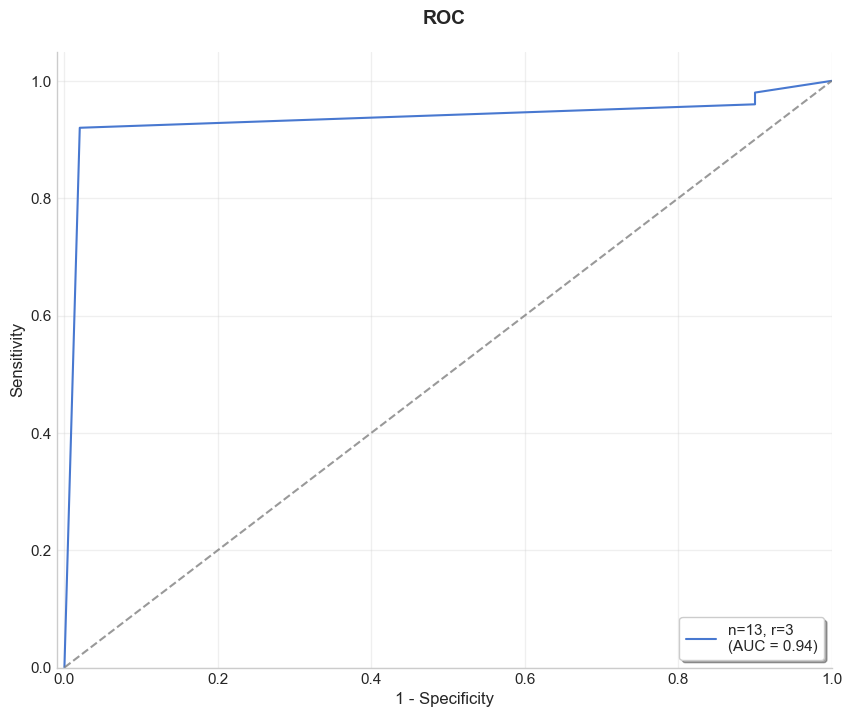

In [77]:
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')
n = 13
r= 3
y_scores = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.1.test",
        n=n,
        r=r
    )

x, y, _ = roc_curve(y_true, y_scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'n={n}, r={r}\n(AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', alpha=0.8)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity', fontsize=12, fontweight='500')
plt.ylabel('Sensitivity', fontsize=12, fontweight='500')
plt.title('ROC', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="lower right", frameon=True, fontsize=11, shadow=True)
plt.grid(alpha=0.3)
plt.show()

## Verification

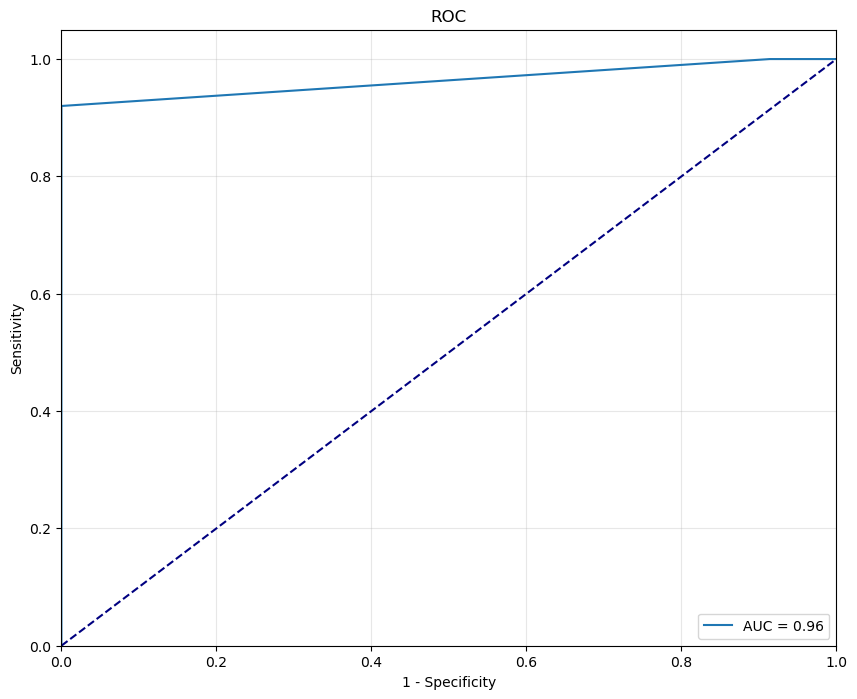

In [7]:
with open("syscalls/snd-cert/snd-cert.2.labels", "r") as f:
    y_true = [int(line.strip()) for line in f]

plt.figure(figsize=(10, 8))

y_scores = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.2.test",
        n=10,
        r=5
    )
x, y, _ = roc_curve(y_true, y_scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'AUC = {auc_score:.2f}')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

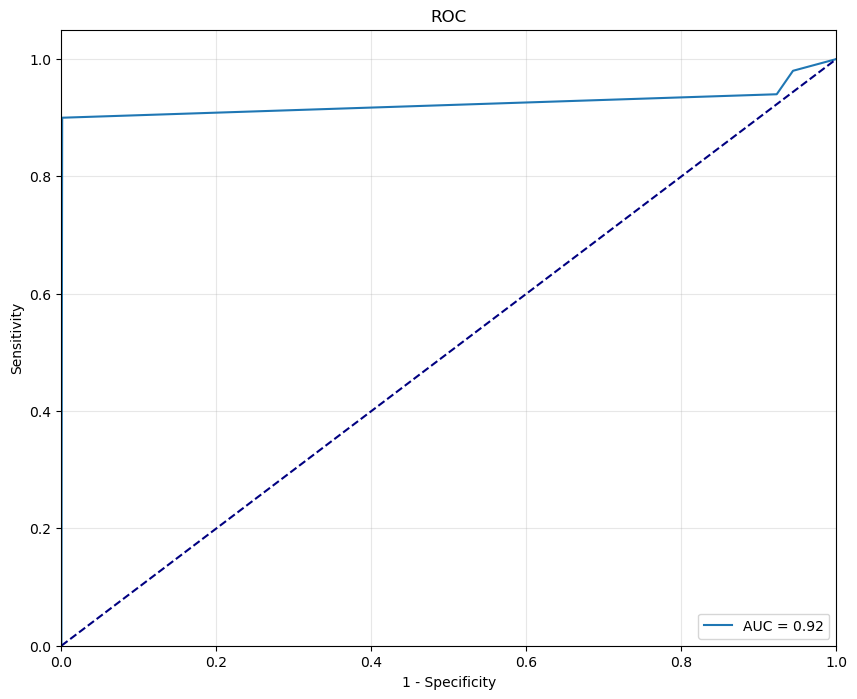

In [8]:
with open("syscalls/snd-cert/snd-cert.3.labels", "r") as f:
    y_true = [int(line.strip()) for line in f]

plt.figure(figsize=(10, 8))

y_scores = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.3.test",
        n=10,
        r=5
    )
x, y, _ = roc_curve(y_true, y_scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'AUC = {auc_score:.2f}')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Other Dataset

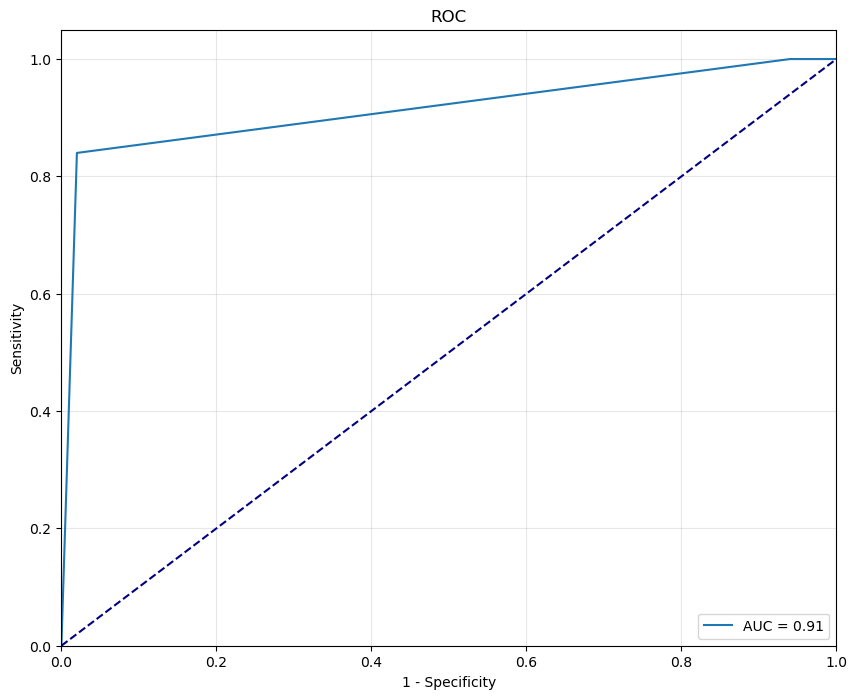

In [9]:
with open("syscalls/snd-unm/snd-unm.1.labels", "r") as f:
    y_true = [int(line.strip()) for line in f]

plt.figure(figsize=(10, 8))

y_scores = pipeline(
        train="syscalls/snd-unm/snd-unm.train",
        alphabet="syscalls/snd-unm/snd-unm.alpha", 
        test="syscalls/snd-unm/snd-unm.1.test",
        n=10,
        r=5
    )
x, y, _ = roc_curve(y_true, y_scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'AUC = {auc_score:.2f}')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()